# 05 · Grad-CAM Visualizations

Show what image regions drive the model's predictions. Grad-CAM backpropagates the predicted class score to the last convolutional layer's activations, weighted by per-channel gradients, to produce a 2D heatmap.

For a plant disease classifier we expect the model to attend to **disease lesions**, not to the leaf background or the image border. If it's looking at the wrong thing, that's a red flag.

## Setup

In [1]:
import sys
sys.path.insert(0, '..')
import torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from src.model import load_checkpoint
from src.dataset import build_eval_transform
from src.gradcam import GradCAM, overlay_heatmap_on_image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
model, class_names = load_checkpoint(
    '../models/plantdoc_resnet50.pt', num_classes=38, device=DEVICE,
)
transform = build_eval_transform()
cam = GradCAM(model, target_layer=model.layer4)

## Grad-CAM on a few samples

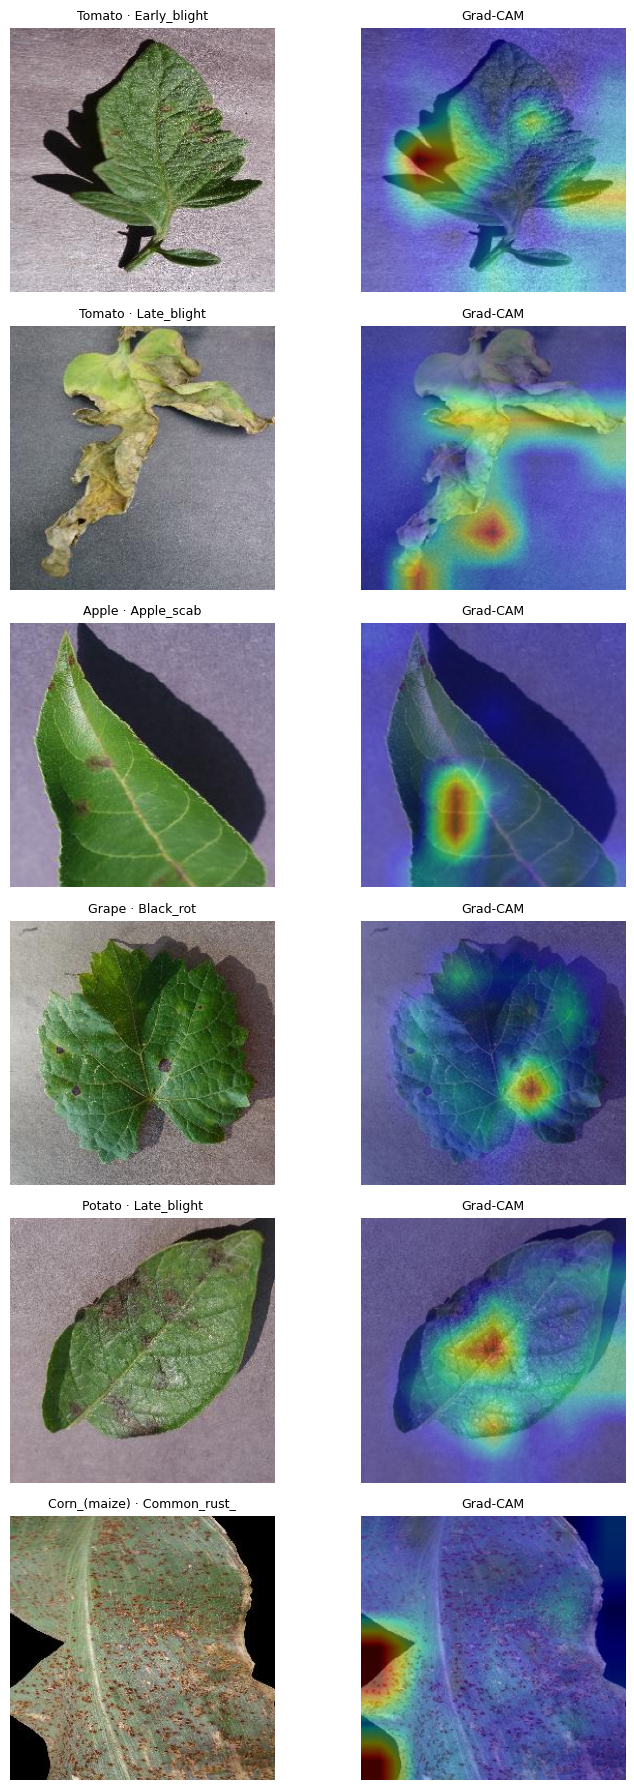

In [3]:
# Pick one sample from each of 6 interesting classes
DATA_DIR = Path('../data/plantvillage/color')
classes_to_visualize = [
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Apple___Apple_scab',
    'Grape___Black_rot',
    'Potato___Late_blight',
    'Corn_(maize)___Common_rust_',
]

fig, axes = plt.subplots(len(classes_to_visualize), 2, figsize=(8, 3*len(classes_to_visualize)))
for row, cls in enumerate(classes_to_visualize):
    # Grab the first image from that class folder
    cls_dir = DATA_DIR / cls
    img_path = next(cls_dir.iterdir())
    img = Image.open(img_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(DEVICE)
    heatmap = cam.generate(x)
    overlay = overlay_heatmap_on_image(img, heatmap)

    axes[row, 0].imshow(img); axes[row, 0].axis('off')
    axes[row, 0].set_title(cls.replace('___', ' · '), fontsize=9)
    axes[row, 1].imshow(overlay); axes[row, 1].axis('off')
    axes[row, 1].set_title('Grad-CAM', fontsize=9)

plt.tight_layout(); plt.savefig('../docs/gradcam_examples.png', dpi=150); plt.show()

## Takeaways

Mixed results, which honestly makes this more interesting than if everything worked perfectly.

The heatmaps look correct for 4/6 classes: Apple Scab, Grape Black Rot, Potato Late Blight, and Tomato Early Blight all show the model concentrating its attention on the actual lesion areas, which is what we want. This gives me confidence that for most diseases the model has learned real disease features and not something sketchy like background texture.

Two cases are more concerning:

- **Tomato Late Blight**: the hottest region is below the leaf on the gray background. The model got the class right, but it's partly using something that isn't the disease. PlantVillage has pretty uniform backgrounds across classes so this might be learned background bias, something to be aware of if we ever want this to generalize to real-world photos with cluttered backgrounds.

- **Corn Common Rust**: heatmap is completely off the leaf, focused on the black area instead of the rust pustules. My best guess is that this is a resolution issue: ResNet-50's layer4 produces a 7x7 spatial grid, and individual rust pustules are tiny and spread across the whole leaf, so Grad-CAM probably can't localize them well. A method with finer spatial granularity might work better here, or training at a higher input resolution.

None of this invalidates the 98% test accuracy, but it does suggest I should be careful about claiming the model "understands" plant disease. For some classes it probably does. For others, especially where disease features are fine-grained or where background cues are class-correlated, we'd need more rigorous testing before deploying this in the wild.Why it sounds like a student and not AI